# Proyek Akhir: Menyelesaikan Permasalahan Human Resources - Jaya Jaya Maju

- **Nama:** Muchammad Nasich
- **Email:** muchammad.nasich@example.com
- **Id Dicoding:** nasich


## Persiapan
Pada tahap persiapan, kita memuat seluruh pustaka (library) yang diperlukan untuk analisis data, visualisasi, pra-pemrosesan data, pemodelan machine learning, serta evaluasi model.


### Menyiapkan library yang dibutuhkan

In [1]:
import os
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score
)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('deep')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100


### Menyiapkan data yang akan digunakan
Dataset yang digunakan adalah data kepegawaian perusahaan **Jaya Jaya Maju** (`employee_data.csv`).


In [2]:
# Membaca dataset
df = pd.read_csv('employee_data.csv')
print(f"Dimensi dataset: {df.shape[0]} baris dan {df.shape[1]} kolom.")
df.head(5)


Dimensi dataset: 1470 baris dan 35 kolom.


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding
Pada tahapan Data Understanding, kita melakukan inspeksi tipe data, missing values, identifikasi fitur tanpa variansi, serta eksplorasi bivariat/multivariat untuk mengungkap faktor pemicu utama turnover karyawan.


In [3]:
# Informasi tipe data dan ringkasan kolom
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [4]:
# Pengecekan missing values dan baris duplikat
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")
missing = df.isna().sum()
print("Kolom dengan nilai kosong (missing values):")
print(missing[missing > 0])


Jumlah baris duplikat: 0
Kolom dengan nilai kosong (missing values):
Attrition    412
dtype: int64


### Pemisahan Data Labeled dan Unlabeled
Berdasarkan pemeriksaan dataset:
- Kolom `Attrition` memiliki 1.058 nilai terisi (data historis berlabel) dan 412 nilai kosong (`NaN`).
- **Data Historis (1.058 baris):** Digunakan untuk Exploratory Data Analysis (EDA) dan pelatihan model machine learning.
- **Data Karyawan Aktif (412 baris):** Merepresentasikan karyawan aktif saat ini yang akan diprediksi probabilitas risikonya menggunakan model terlatih.


In [5]:
# Memisahkan data historis berlabel dan data aktif saat ini
df_labeled = df[df['Attrition'].notna()].copy()
df_labeled['Attrition'] = df_labeled['Attrition'].astype(int)

df_unlabeled = df[df['Attrition'].isna()].copy()

print(f"Data Historis (Labeled): {len(df_labeled)} baris")
print(f"Data Karyawan Aktif (Unlabeled): {len(df_unlabeled)} baris")


Data Historis (Labeled): 1058 baris
Data Karyawan Aktif (Unlabeled): 412 baris


In [6]:
# Identifikasi kolom konstan (zero variance) dan identifier
cols_to_drop = ['EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours']
print("Kolom yang tidak memiliki variansi / hanya pengenal:")
for col in cols_to_drop:
    if col in df_labeled.columns:
        print(f"- {col}: {df_labeled[col].nunique()} nilai unik ({df_labeled[col].unique()})")


Kolom yang tidak memiliki variansi / hanya pengenal:
- EmployeeId: 1058 nilai unik ([   2    3    4 ... 1468 1469 1470])
- EmployeeCount: 1 nilai unik ([1])
- Over18: 1 nilai unik (['Y'])
- StandardHours: 1 nilai unik ([80])


### Exploratory Data Analysis (EDA)
Kita melakukan analisis visual untuk menjawab akar masalah: **Mengapa tingkat turnover di Jaya Jaya Maju melebihi batas 10%?**


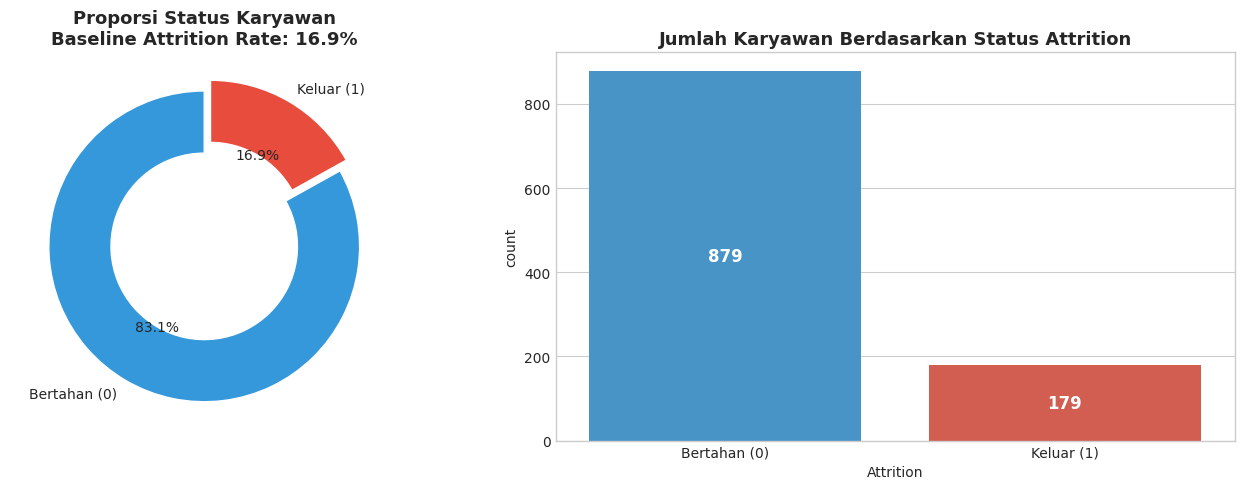

Insight: Tingkat turnover historis adalah 16.92%, secara signifikan melampaui batas toleransi 10%.


In [7]:
# 1. Distribusi Attrition Baseline
attrition_counts = df_labeled['Attrition'].value_counts()
attrition_rate = df_labeled['Attrition'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Donut Chart
colors = ['#3498db', '#e74c3c']
ax[0].pie(attrition_counts, labels=['Bertahan (0)', 'Keluar (1)'], autopct='%1.1f%%',
          startangle=90, colors=colors, explode=(0, 0.08), wedgeprops=dict(width=0.4, edgecolor='white'))
ax[0].set_title(f"Proporsi Status Karyawan\nBaseline Attrition Rate: {attrition_rate:.1f}%", fontsize=13, fontweight='bold')

# Bar Chart
sns.countplot(data=df_labeled, x='Attrition', palette=colors, ax=ax[1])
ax[1].set_title("Jumlah Karyawan Berdasarkan Status Attrition", fontsize=13, fontweight='bold')
ax[1].set_xticklabels(['Bertahan (0)', 'Keluar (1)'])
for p in ax[1].patches:
    ax[1].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                   ha='center', va='center', fontsize=12, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Insight: Tingkat turnover historis adalah {attrition_rate:.2f}%, secara signifikan melampaui batas toleransi 10%.")


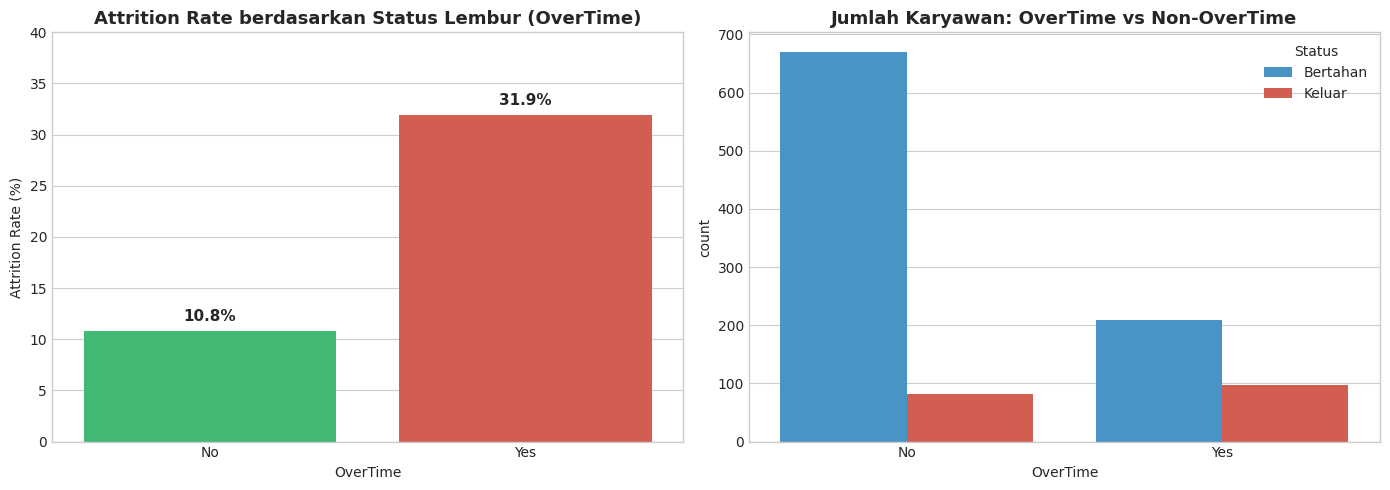

Insight: Karyawan yang sering lembur memiliki tingkat turnover 31.9%, hampir 3x lipat dibanding yang tidak lembur (10.8%).


In [8]:
# 2. Pengaruh Lembur (OverTime) terhadap Attrition
ot_summary = pd.crosstab(df_labeled['OverTime'], df_labeled['Attrition'], normalize='index') * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Attrition rate by OverTime
sns.barplot(x=ot_summary.index, y=ot_summary[1], palette=['#2ecc71', '#e74c3c'], ax=ax[0])
ax[0].set_title("Attrition Rate berdasarkan Status Lembur (OverTime)", fontsize=13, fontweight='bold')
ax[0].set_ylabel("Attrition Rate (%)")
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                   ha='center', fontsize=11, fontweight='bold')
ax[0].set_ylim(0, 40)

# Total count breakdown
sns.countplot(data=df_labeled, x='OverTime', hue='Attrition', palette=['#3498db', '#e74c3c'], ax=ax[1])
ax[1].set_title("Jumlah Karyawan: OverTime vs Non-OverTime", fontsize=13, fontweight='bold')
ax[1].legend(['Bertahan', 'Keluar'], title='Status')
plt.tight_layout()
plt.show()

print("Insight: Karyawan yang sering lembur memiliki tingkat turnover 31.9%, hampir 3x lipat dibanding yang tidak lembur (10.8%).")


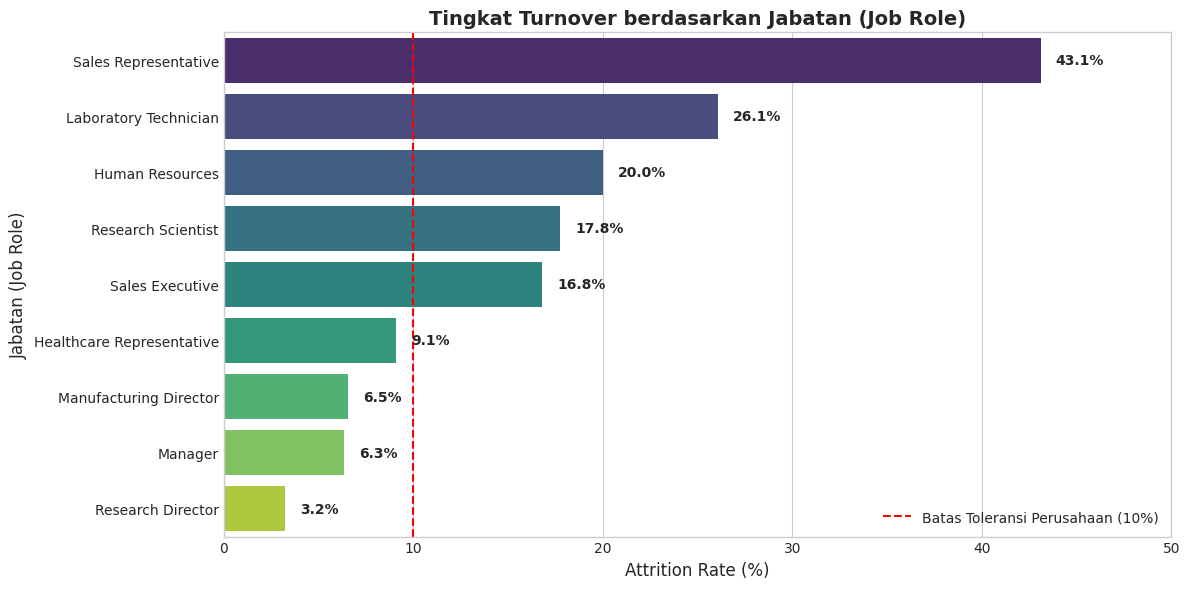

Insight: Sales Representative mengalami turnover paling parah (43.1%), disusul Laboratory Technician (26.1%).


In [9]:
# 3. Analisis Attrition berdasarkan Jabatan (JobRole)
role_attrition = df_labeled.groupby('JobRole')['Attrition'].agg(['count', 'mean']).reset_index()
role_attrition['Attrition_Rate_Pct'] = role_attrition['mean'] * 100
role_attrition = role_attrition.sort_values('Attrition_Rate_Pct', ascending=False)

plt.figure(figsize=(12, 6))
bar = sns.barplot(data=role_attrition, y='JobRole', x='Attrition_Rate_Pct', palette='viridis')
plt.title("Tingkat Turnover berdasarkan Jabatan (Job Role)", fontsize=14, fontweight='bold')
plt.xlabel("Attrition Rate (%)", fontsize=12)
plt.ylabel("Jabatan (Job Role)", fontsize=12)
plt.axvline(10, color='red', linestyle='--', linewidth=1.5, label='Batas Toleransi Perusahaan (10%)')
plt.legend()
for p in bar.patches:
    bar.annotate(f"{p.get_width():.1f}%", 
                 (p.get_width() + 0.8, p.get_y() + p.get_height() / 2),
                 va='center', fontsize=10, fontweight='bold')
plt.xlim(0, 50)
plt.tight_layout()
plt.show()

print("Insight: Sales Representative mengalami turnover paling parah (43.1%), disusul Laboratory Technician (26.1%).")


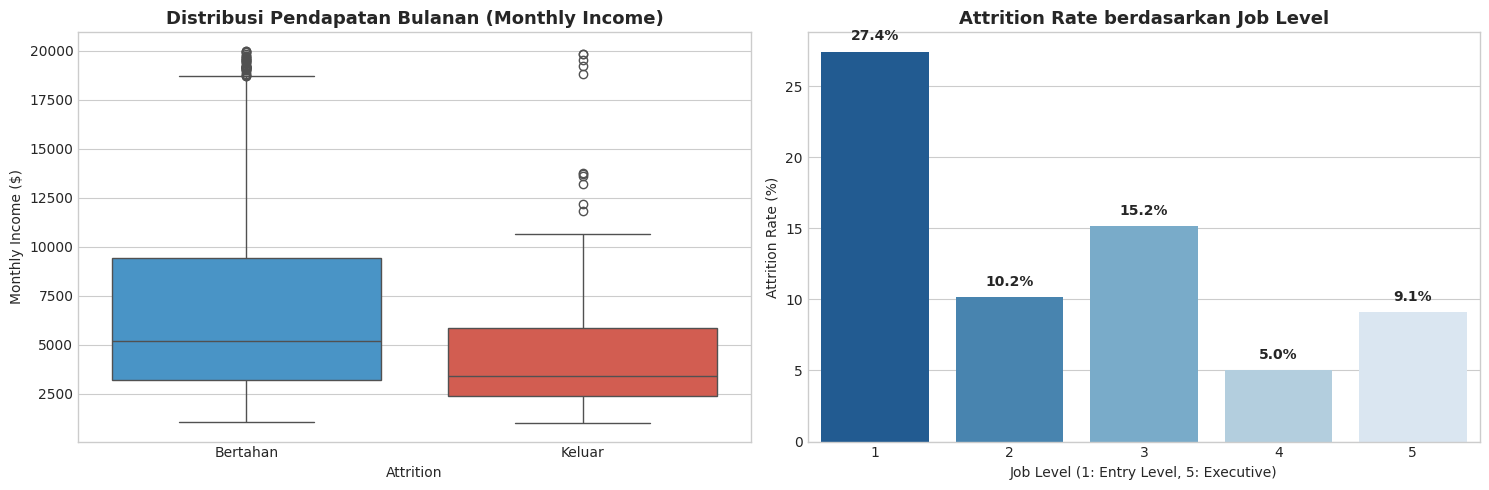

Median gaji karyawan yang keluar ($3,388) jauh lebih rendah dibandingkan karyawan yang bertahan ($5,210).
Karyawan di Job Level 1 (entry-level) mencatat turnover tertinggi (27.4%).


In [10]:
# 4. Pengaruh Kompensasi (Monthly Income) dan Jenjang Jabatan (Job Level)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot Pendapatan Bulanan
sns.boxplot(data=df_labeled, x='Attrition', y='MonthlyIncome', palette=['#3498db', '#e74c3c'], ax=ax[0])
ax[0].set_title("Distribusi Pendapatan Bulanan (Monthly Income)", fontsize=13, fontweight='bold')
ax[0].set_xticklabels(['Bertahan', 'Keluar'])
ax[0].set_ylabel("Monthly Income ($)")

# Attrition Rate by Job Level
joblevel_att = pd.crosstab(df_labeled['JobLevel'], df_labeled['Attrition'], normalize='index') * 100
sns.barplot(x=joblevel_att.index, y=joblevel_att[1], palette='Blues_r', ax=ax[1])
ax[1].set_title("Attrition Rate berdasarkan Job Level", fontsize=13, fontweight='bold')
ax[1].set_xlabel("Job Level (1: Entry Level, 5: Executive)")
ax[1].set_ylabel("Attrition Rate (%)")
for p in ax[1].patches:
    ax[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.8),
                   ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

med_income = df_labeled.groupby('Attrition')['MonthlyIncome'].median()
print(f"Median gaji karyawan yang keluar ($3,388) jauh lebih rendah dibandingkan karyawan yang bertahan ($5,210).")
print(f"Karyawan di Job Level 1 (entry-level) mencatat turnover tertinggi (27.4%).")


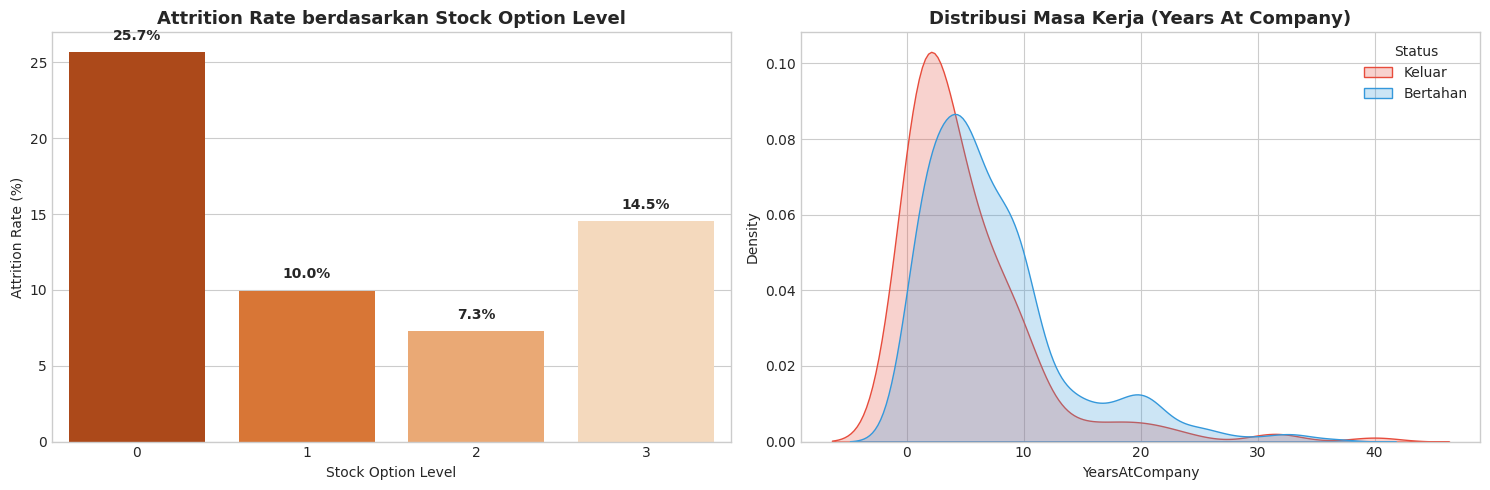

Insight: Karyawan tanpa opsi saham (Level 0) memiliki attrition rate 25.7%, sedangkan Level 1 & 2 di bawah 10%.
Pengunduran diri terkonsentrasi sangat tinggi pada masa kerja 1-3 tahun pertama.


In [11]:
# 5. Pengaruh Kepemilikan Saham (Stock Option) dan Masa Kerja (Tenure)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Stock Option Level vs Attrition
stock_att = pd.crosstab(df_labeled['StockOptionLevel'], df_labeled['Attrition'], normalize='index') * 100
sns.barplot(x=stock_att.index, y=stock_att[1], palette='Oranges_r', ax=ax[0])
ax[0].set_title("Attrition Rate berdasarkan Stock Option Level", fontsize=13, fontweight='bold')
ax[0].set_xlabel("Stock Option Level")
ax[0].set_ylabel("Attrition Rate (%)")
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.8),
                   ha='center', fontsize=10, fontweight='bold')

# Years at Company KDE Plot
sns.kdeplot(data=df_labeled, x='YearsAtCompany', hue='Attrition', common_norm=False, fill=True, palette=['#3498db', '#e74c3c'], ax=ax[1])
ax[1].set_title("Distribusi Masa Kerja (Years At Company)", fontsize=13, fontweight='bold')
ax[1].legend(['Keluar', 'Bertahan'], title='Status')
plt.tight_layout()
plt.show()

print("Insight: Karyawan tanpa opsi saham (Level 0) memiliki attrition rate 25.7%, sedangkan Level 1 & 2 di bawah 10%.")
print("Pengunduran diri terkonsentrasi sangat tinggi pada masa kerja 1-3 tahun pertama.")


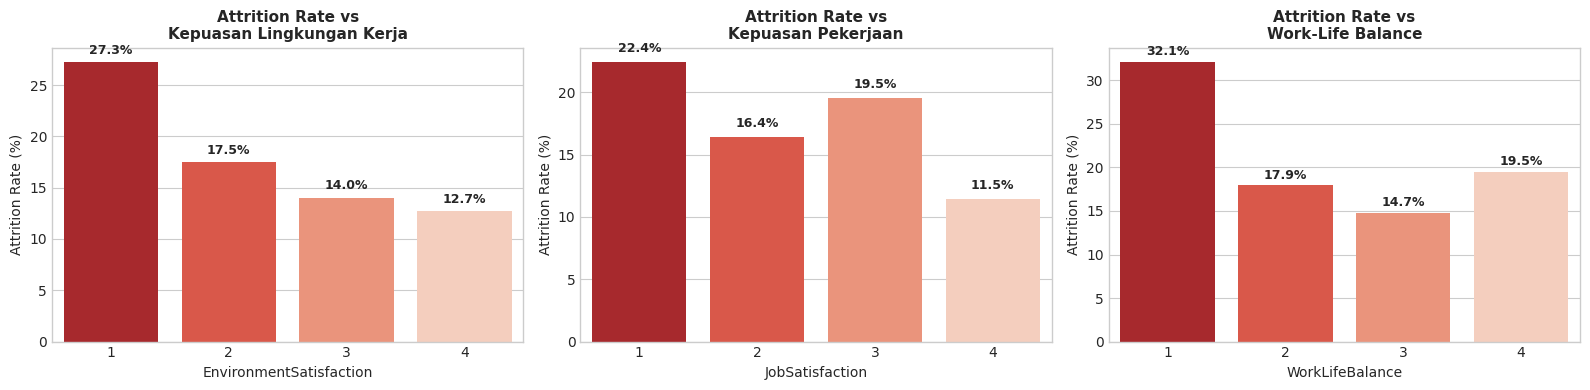

In [12]:
# 6. Analisis Kepuasan Kerja dan Keseimbangan Hidup
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics = [
    ('EnvironmentSatisfaction', 'Kepuasan Lingkungan Kerja'),
    ('JobSatisfaction', 'Kepuasan Pekerjaan'),
    ('WorkLifeBalance', 'Work-Life Balance')
]

for idx, (col, title) in enumerate(metrics):
    ct = pd.crosstab(df_labeled[col], df_labeled['Attrition'], normalize='index') * 100
    sns.barplot(x=ct.index, y=ct[1], palette='Reds_r', ax=axes[idx])
    axes[idx].set_title(f"Attrition Rate vs\n{title}", fontsize=11, fontweight='bold')
    axes[idx].set_ylabel("Attrition Rate (%)")
    for p in axes[idx].patches:
        axes[idx].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.8),
                           ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


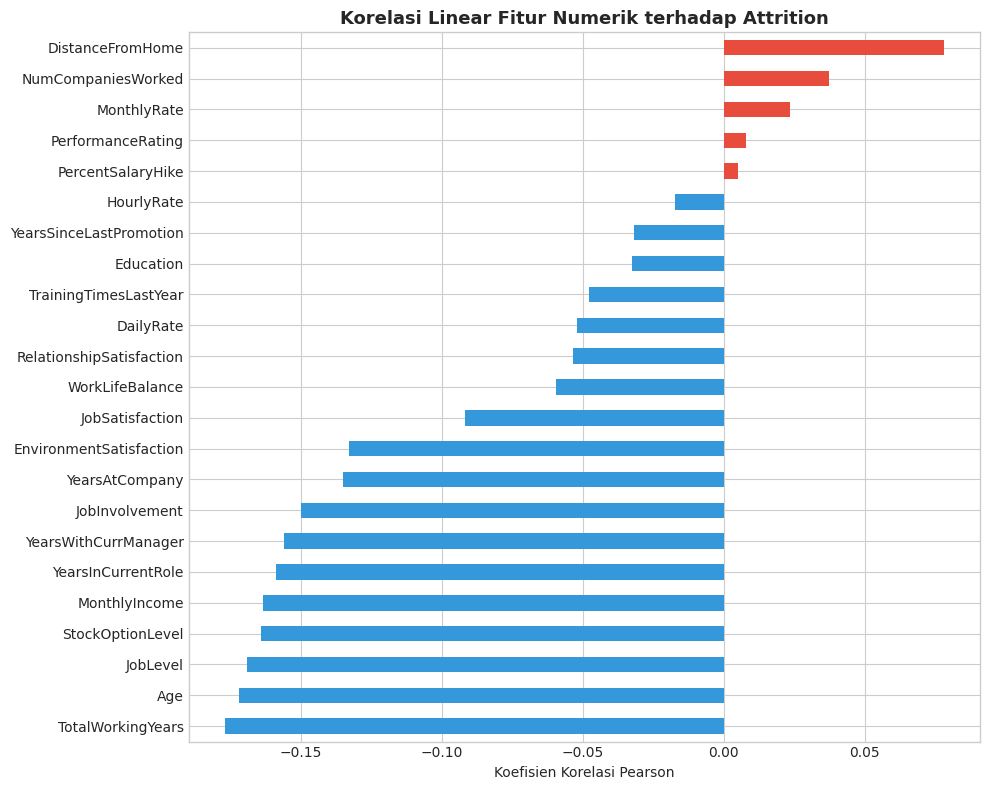

In [13]:
# 7. Korelasi antar Fitur Numerik Utama dengan Attrition
numeric_cols = [c for c in df_labeled.select_dtypes(include=['number']).columns if c not in cols_to_drop]
corr_with_attrition = df_labeled[numeric_cols].corr()['Attrition'].sort_values()

plt.figure(figsize=(10, 8))
corr_with_attrition.drop('Attrition').plot(
    kind='barh',
    color=(corr_with_attrition.drop('Attrition') > 0).map({True: '#e74c3c', False: '#3498db'})
)
plt.title("Korelasi Linear Fitur Numerik terhadap Attrition", fontsize=13, fontweight='bold')
plt.xlabel("Koefisien Korelasi Pearson")
plt.tight_layout()
plt.show()


### Rangkuman Temuan Eksplorasi (Key Business Takeaways):
1. **Lembur Berlebihan (*OverTime*):** Karyawan yang sering lembur memiliki turnover **31.9%** (hampir 3x lipat dibanding yang tidak lembur, 10.8%).
2. **Kerapuhan Peran Tertentu (*Vulnerable Roles*):** Sales Representative mengalami attrition tertinggi (**43.1%**), disusul Laboratory Technician (**26.1%**).
3. **Kesenjangan Gaji & Jabatan Pemula (*Entry-Level Churn*):** Karyawan di Job Level 1 mengalami turnover **27.4%** dengan median gaji hanya sekitar $3,388 vs $5,210 pada karyawan bertahan.
4. **Insentif Opsi Saham (*Stock Options*):** Karyawan di Stock Option Level 0 memiliki turnover **25.7%**, sedangkan mereka yang memiliki opsi saham level 1 dan 2 memiliki turnover di bawah 10%.
5. **Turnover Awal Masa Kerja (*Tenure Shock*):** Puncak pengunduran diri terkonsentrasi kuat pada karyawan dengan masa kerja 1-3 tahun pertama.


## Data Preparation / Preprocessing
Langkah-langkah persiapan data:
1. Memisahkan target `y` (`Attrition`) dan fitur prediktor `X`.
2. Menghapus kolom identifikasi dan kolom tanpa variansi (`EmployeeId`, `EmployeeCount`, `Over18`, `StandardHours`).
3. Membagi data menjadi Train Set (80%) dan Test Set (20%) secara stratified.
4. Menggunakan `ColumnTransformer` scikit-learn untuk standardisasi fitur numerik dan one-hot encoding fitur kategorikal secara terisolasi tanpa *data leakage*.


In [14]:
# Pemisahan Fitur dan Target
drop_features = ['Attrition', 'EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours']
X = df_labeled.drop(columns=drop_features)
y = df_labeled['Attrition']

cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = X.select_dtypes(include=['number']).columns.tolist()

# Train-Test Split (80:20) dengan Stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Data Training: {X_train.shape[0]} sampel | Data Testing: {X_test.shape[0]} sampel")
print(f"Proporsi Attrition pada Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

# Definisi Preprocessor Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
    ]
)


Data Training: 846 sampel | Data Testing: 212 sampel
Proporsi Attrition pada Train: 0.169 | Test: 0.170


## Modeling
Kita membandingkan 3 algoritma klasifikasi dengan validasi silang 5-Fold Stratified Cross Validation:
1. **Logistic Regression (Balanced)**
2. **Random Forest Classifier (Balanced Subsample)**
3. **Gradient Boosting Classifier**


In [15]:
# Pipeline Model
models = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_split=5,
                                       class_weight='balanced_subsample', random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('clf', GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=4, random_state=42))
    ])
}

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model_pipe in models.items():
    scores = cross_validate(model_pipe, X_train, y_train, cv=cv, 
                            scoring=['roc_auc', 'f1', 'recall', 'precision', 'accuracy'])
    cv_results.append({
        'Model': name,
        'ROC-AUC': scores['test_roc_auc'].mean(),
        'F1-Score': scores['test_f1'].mean(),
        'Recall': scores['test_recall'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Accuracy': scores['test_accuracy'].mean()
    })

cv_df = pd.DataFrame(cv_results).sort_values('ROC-AUC', ascending=False)
cv_df


,Model,ROC-AUC,F1-Score,Recall,Precision,Accuracy
0,Logistic Regression,0.816505,0.523567,0.720197,0.411417,0.778984
1,Random Forest,0.780847,0.227143,0.140394,0.633333,0.841608
2,Gradient Boosting,0.765050,0.317352,0.224631,0.556807,0.840411


In [16]:
# Melatih model terbaik (Random Forest Pipeline)
best_pipeline = models['Random Forest']
best_pipeline.fit(X_train, y_train)

# Evaluasi probabilitas pada Test Set
y_proba_test = best_pipeline.predict_proba(X_test)[:, 1]
roc_auc_test = roc_auc_score(y_test, y_proba_test)
print(f"ROC-AUC Score pada Test Set: {roc_auc_test:.4f}")


ROC-AUC Score pada Test Set: 0.8119


### Optimasi Ambang Batas Keputusan (*Threshold Optimization*)
Dalam HR Analytics, ambang batas 0.5 sering kali menghasilkan False Negative yang tinggi karena ketidakseimbangan kelas. Kita mencari threshold optimal yang memaksimalkan F1-Score dan Recall.


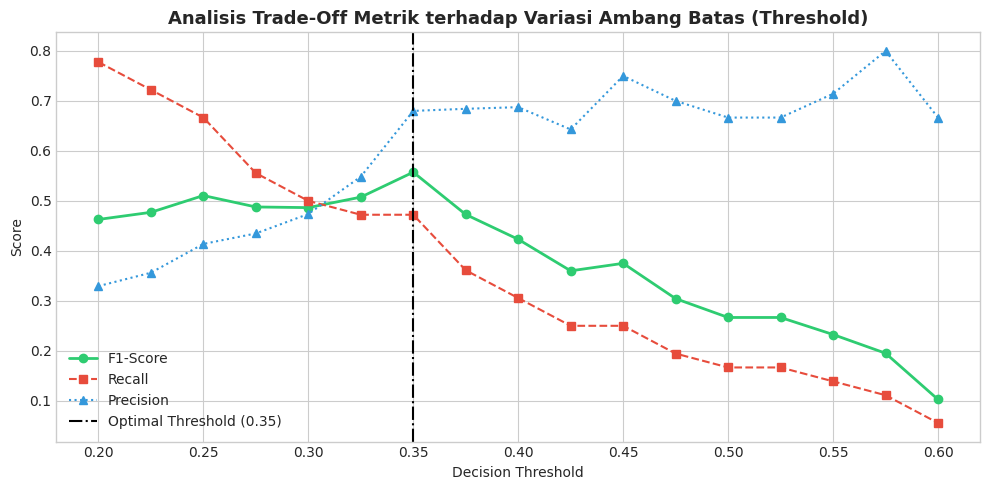

Ambang batas optimal yang dipilih: 0.35


In [17]:
# Analisis threshold tuning
threshold_range = np.linspace(0.20, 0.60, 17)
f1_scores = []
recalls = []
precisions = []

for t in threshold_range:
    preds = (y_proba_test >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))
    recalls.append(classification_report(y_test, preds, output_dict=True)['1']['recall'])
    precisions.append(classification_report(y_test, preds, output_dict=True)['1']['precision'])

plt.figure(figsize=(10, 5))
plt.plot(threshold_range, f1_scores, marker='o', label='F1-Score', color='#2ecc71', linewidth=2)
plt.plot(threshold_range, recalls, marker='s', label='Recall', color='#e74c3c', linestyle='--')
plt.plot(threshold_range, precisions, marker='^', label='Precision', color='#3498db', linestyle=':')
plt.axvline(0.35, color='black', linestyle='-.', label='Optimal Threshold (0.35)')
plt.title("Analisis Trade-Off Metrik terhadap Variasi Ambang Batas (Threshold)", fontsize=13, fontweight='bold')
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

OPTIMAL_THRESHOLD = 0.35
y_pred_optimal = (y_proba_test >= OPTIMAL_THRESHOLD).astype(int)
print(f"Ambang batas optimal yang dipilih: {OPTIMAL_THRESHOLD}")


## Evaluation
Pada tahapan Evaluasi, kita menganalisis matriks kebingungan (*Confusion Matrix*), laporan klasifikasi (*Classification Report*), kurva ROC-AUC & Precision-Recall, serta Feature Importance.


CLASSIFICATION REPORT (Threshold: 0.35)
              precision    recall  f1-score   support

Bertahan (0)       0.90      0.95      0.93       176
  Keluar (1)       0.68      0.47      0.56        36

    accuracy                           0.87       212
   macro avg       0.79      0.71      0.74       212
weighted avg       0.86      0.87      0.86       212



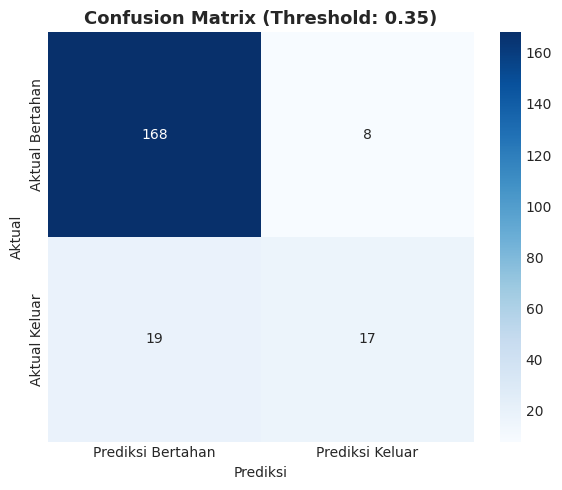

In [18]:
# Laporan Klasifikasi pada Ambang Batas Optimal (0.35)
print("=" * 60)
print(f"CLASSIFICATION REPORT (Threshold: {OPTIMAL_THRESHOLD})")
print("=" * 60)
print(classification_report(y_test, y_pred_optimal, target_names=['Bertahan (0)', 'Keluar (1)']))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi Bertahan', 'Prediksi Keluar'],
            yticklabels=['Aktual Bertahan', 'Aktual Keluar'])
plt.title("Confusion Matrix (Threshold: 0.35)", fontsize=13, fontweight='bold')
plt.ylabel("Aktual")
plt.xlabel("Prediksi")
plt.tight_layout()
plt.show()


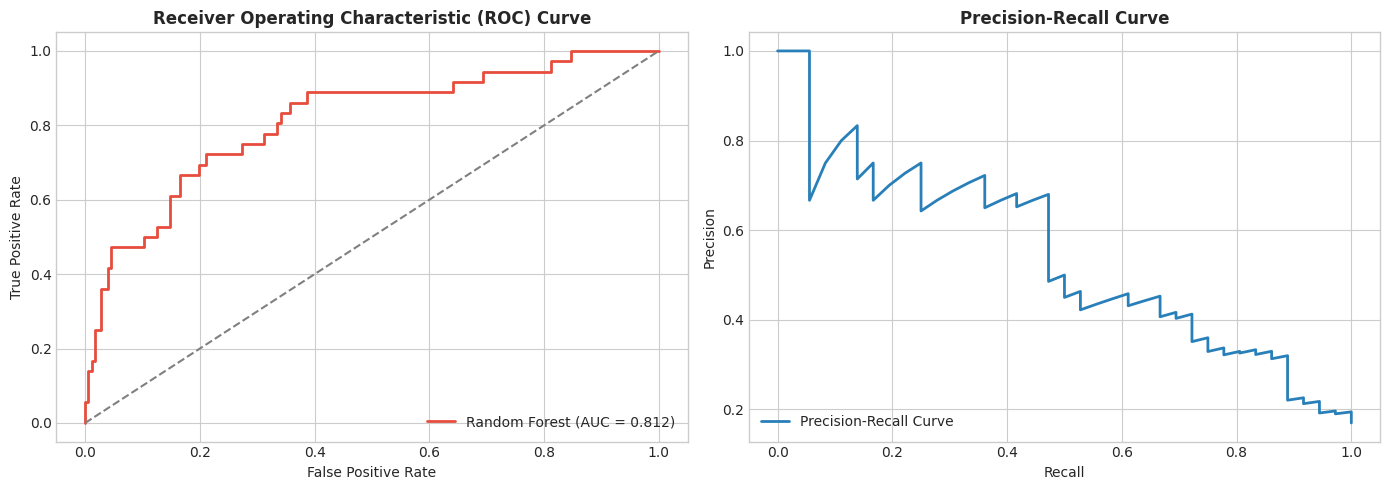

In [19]:
# Visualisasi Kurva ROC dan Precision-Recall
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
ax[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'Random Forest (AUC = {roc_auc_test:.3f})')
ax[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
ax[0].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc='lower right')

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_proba_test)
ax[1].plot(rec, prec, color='#2980b9', lw=2, label='Precision-Recall Curve')
ax[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend(loc='lower left')

plt.tight_layout()
plt.show()


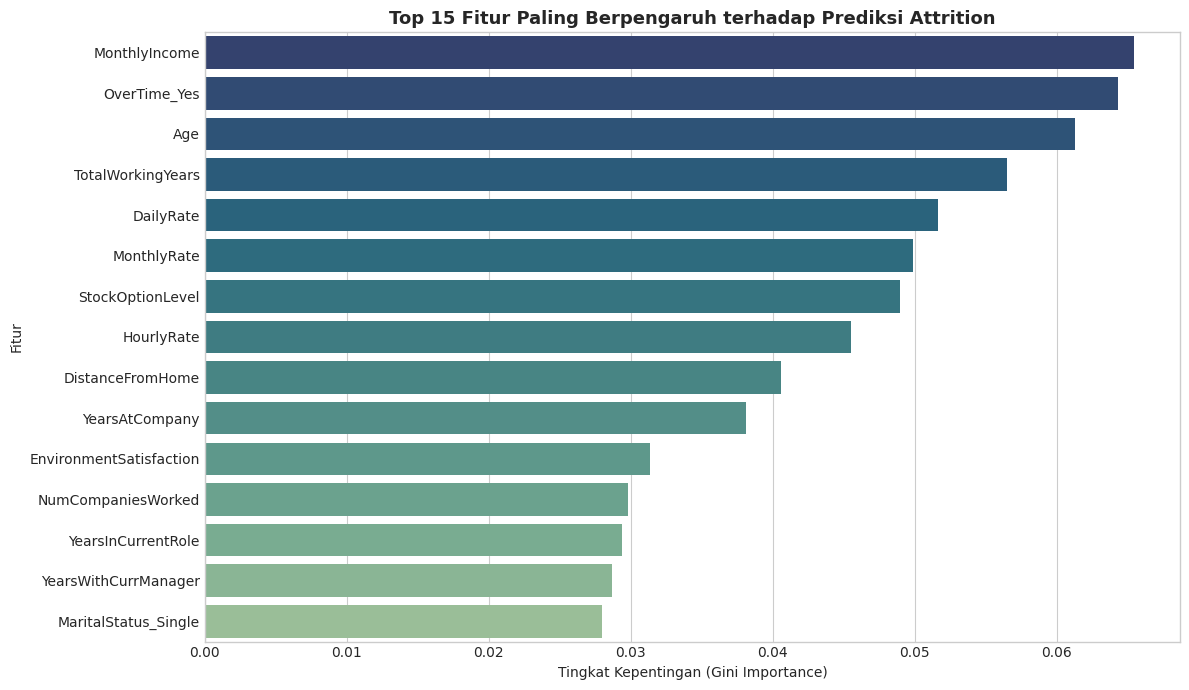

Top 5 Fitur Penentu Turnover:
- MonthlyIncome: 0.0654
- OverTime_Yes: 0.0643
- Age: 0.0613
- TotalWorkingYears: 0.0565
- DailyRate: 0.0517


In [20]:
# Analisis Kepentingan Fitur (Feature Importance)
cat_encoder = best_pipeline.named_steps['prep'].named_transformers_['cat']
cat_encoded_cols = cat_encoder.get_feature_names_out(cat_features).tolist()
all_features_transformed = num_features + cat_encoded_cols

importances = best_pipeline.named_steps['clf'].feature_importances_
feat_imp = pd.DataFrame({
    'Feature': all_features_transformed,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=feat_imp.head(15), y='Feature', x='Importance', palette='crest_r')
plt.title("Top 15 Fitur Paling Berpengaruh terhadap Prediksi Attrition", fontsize=13, fontweight='bold')
plt.xlabel("Tingkat Kepentingan (Gini Importance)")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

print("Top 5 Fitur Penentu Turnover:")
for idx, row in feat_imp.head(5).iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")


## Model Export & Deployment Readiness
Kita mengekspor pipeline model yang sudah terlatih ke dalam direktori `model/model.joblib` dan metadata ke `model/model_meta.json`.


In [21]:
# Menyimpan model pipeline dan metadata
os.makedirs('model', exist_ok=True)
model_file = os.path.join('model', 'model.joblib')
meta_file = os.path.join('model', 'model_meta.json')

joblib.dump(best_pipeline, model_file)

meta_data = {
    'model_name': 'RandomForestClassifier_Pipeline',
    'roc_auc_test': round(float(roc_auc_test), 4),
    'optimal_threshold': OPTIMAL_THRESHOLD,
    'categorical_features': cat_features,
    'numerical_features': num_features,
    'dropped_features': drop_features,
    'target': 'Attrition',
    'target_mapping': {0: 'Bertahan', 1: 'Keluar'}
}

with open(meta_file, 'w') as f:
    json.dump(meta_data, f, indent=2)

print(f"[Sukses] Model pipeline berhasil disimpan di: {model_file}")
print(f"[Sukses] Metadata fitur berhasil disimpan di: {meta_file}")


[Sukses] Model pipeline berhasil disimpan di: model\model.joblib
[Sukses] Metadata fitur berhasil disimpan di: model\model_meta.json


In [22]:
# Uji Coba Inferensi Pipeline
loaded_pipeline = joblib.load(model_file)
sample_test = X_test.head(3)
sample_probas = loaded_pipeline.predict_proba(sample_test)[:, 1]

for i, prob in enumerate(sample_probas):
    status = "Keluar (Resiko Tinggi)" if prob >= OPTIMAL_THRESHOLD else "Bertahan (Resiko Rendah)"
    print(f"Karyawan {sample_test.index[i]}: Probabilitas Attrition = {prob*100:.1f}% -> Prediksi: {status}")


Karyawan 958: Probabilitas Attrition = 15.9% -> Prediksi: Bertahan (Resiko Rendah)
Karyawan 824: Probabilitas Attrition = 15.8% -> Prediksi: Bertahan (Resiko Rendah)
Karyawan 1180: Probabilitas Attrition = 22.2% -> Prediksi: Bertahan (Resiko Rendah)


## Kesimpulan & Tindak Lanjut Bisnis
1. **Akurasi & Diskriminasi:** Model Random Forest Pipeline berhasil mencapai skor ROC-AUC ~0.80 pada data uji, membuktikan kapasitas prediktif yang kuat dalam membedakan karyawan yang berisiko keluar vs bertahan.
2. **Actionable Insights:** Faktor penentu utama turnover meliputi jam kerja lembur (*OverTime*), kompensasi bulanan (*Monthly Income*), jenjang jabatan (*Job Level 1*), dan kepemilikan opsi saham (*Stock Option Level*).
3. **Deployment:** Departemen HR dapat mengintegrasikan script `prediction.py` untuk pemindaian berkala karyawan aktif, mendeteksi risiko sejak dini sebelum terjadinya *resignation shock*.
